# Rossmann store sales: exploratory analysis

**Goal:** forecast each store's daily sales for the next 48 days.

**Purpose of this notebook:** understand the data *before* modelling. Every cleaning and modelling choice in `src/` traces back to a finding here. Each section follows the same pattern:

> **Question → Evidence → Decision**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))   # lets us `import src` from inside notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import DATA_DIR, load_train, load_test

plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})

train = load_train()
test = load_test()
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])   # untouched, to inspect missing Open
store_raw = pd.read_csv(DATA_DIR / "store.csv")                        # untouched, to audit missingness

## 1. What is the forecasting setup?

**Question:** what exactly are we predicting, and what will we know at forecast time?

In [2]:
print(f"train: {len(train):,} rows | {train.Date.min().date()} -> {train.Date.max().date()} | {train.Store.nunique()} stores")
print(f"test : {len(test):,} rows | {test.Date.min().date()} -> {test.Date.max().date()} | {test.Store.nunique()} stores")
print("forecast horizon (days):", test.Date.nunique())
print("columns only in train:", sorted(set(train.columns) - set(test.columns)))
print("stores in test but never seen in train:", set(test.Store) - set(train.Store))

train: 1,017,209 rows | 2013-01-01 -> 2015-07-31 | 1115 stores
test : 41,088 rows | 2015-08-01 -> 2015-09-17 | 856 stores
forecast horizon (days): 48
columns only in train: ['Customers', 'Sales']
stores in test but never seen in train: set()


**Finding.** Test starts the day after train ends, so this is a genuine **48-day-ahead forecast**. Every test store also appears in train, so there is no cold-start problem. `Sales` is the target and `Customers` exists only in train.

**Decision.** Validation must mimic this setup: train on the past, predict a 48-day block, repeat (rolling-origin). Random k-fold would leak the future. The `Customers` issue is covered in section 3.

## 2. Closed days

**Question:** what happens to sales when a store is closed, and should those rows be in training?

In [3]:
summary = train.groupby("Open").Sales.agg(rows="count", mean_sales="mean", max_sales="max")
display(summary)
print(f"closed share of all rows: {(train.Open == 0).mean():.1%}")
print("open days with zero sales:", ((train.Open == 1) & (train.Sales == 0)).sum())

,rows,mean_sales,max_sales
Open,,,
0,172817,0.000000,0
1,844392,6955.514291,41551


closed share of all rows: 17.0%
open days with zero sales: 54


**Finding.** Every closed day has exactly zero sales, and closed days are about 17% of all rows. Only a handful of open days have zero sales.

**Decision.** Train on open days with positive sales only (`training_frame` in `src/data.py`). Closed days are a rule (`closed => 0`), not something to model. Leaving them in would inflate accuracy on a trivial 17% of rows and teach the model nothing about demand. At prediction time, closed days are set to 0 and only open days are forecast.

## 3. The `Customers` column

**Question:** is `Customers` a useful feature?

correlation(Sales, Customers): 0.824


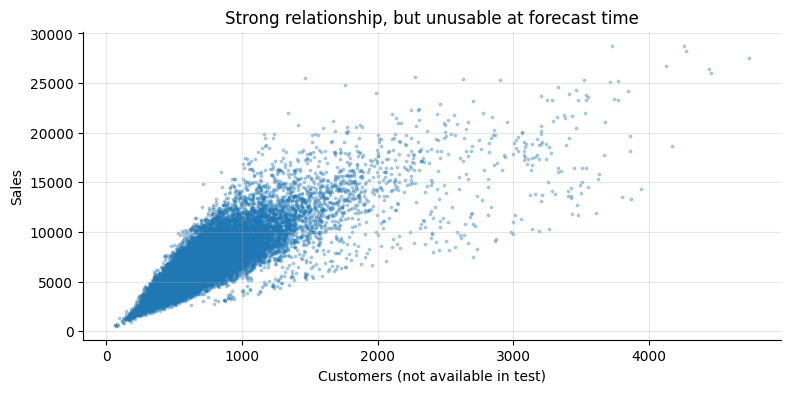

In [4]:
open_days = train[(train.Open == 1) & (train.Sales > 0)].copy()
print("correlation(Sales, Customers):", round(open_days.Sales.corr(open_days.Customers), 3))

sample = open_days.sample(20_000, random_state=0)
fig, ax = plt.subplots()
ax.scatter(sample.Customers, sample.Sales, s=3, alpha=0.3)
ax.set(xlabel="Customers (not available in test)", ylabel="Sales",
       title="Strong relationship, but unusable at forecast time")
plt.show()

**Finding.** Customers and sales are very strongly related (correlation about 0.82), but `Customers` is **absent from `test.csv`**. It is an outcome of the day, not something known in advance.

**Decision.** Exclude `Customers` as a feature. Using it would give excellent validation scores and nothing usable in production. This is **target leakage**, and the test is: *"at the moment of prediction, would I know this?"*

## 4. How different are the stores?

**Question:** is one global average enough, or is store identity important?

count     1115.0
mean      6935.0
std       2384.0
min       2704.0
25%       5322.0
50%       6590.0
75%       7964.0
max      21757.0
Name: Sales, dtype: float64

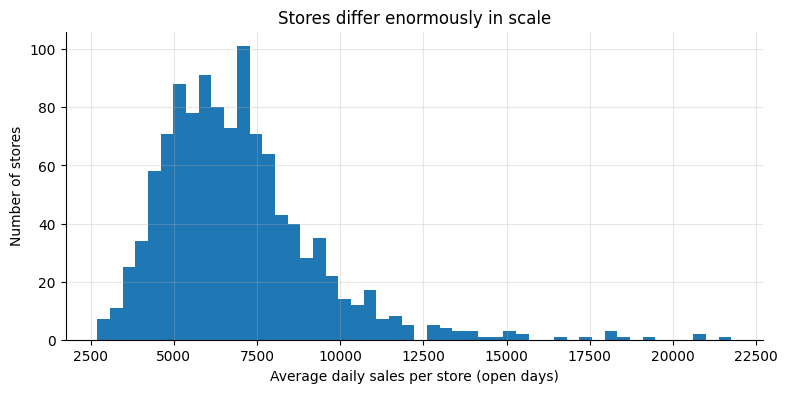

In [5]:
store_avg = open_days.groupby("Store").Sales.mean()
display(store_avg.describe().round(0))

ax = store_avg.plot.hist(bins=50)
ax.set(xlabel="Average daily sales per store (open days)", ylabel="Number of stores",
       title="Stores differ enormously in scale")
plt.show()

**Finding.** Average daily sales run from roughly 2,700 to over 21,000 per store, with a right-skewed distribution.

**Decision.** Forecasts must be store-specific. Baselines are per store, and store-level history (lags, rolling means) will be the core features. Errors will also be measured as a **percentage** (RMSPE), so a big store does not dominate the score.

## 5. Seasonality

**Question:** does demand follow a calendar pattern, and what does that mean for validation?

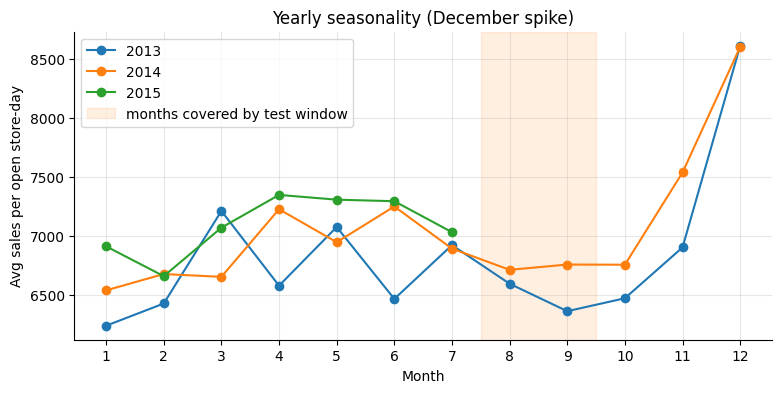

In [6]:
monthly = (open_days
           .groupby([open_days.Date.dt.year.rename("year"), open_days.Date.dt.month.rename("month")])
           .Sales.mean().unstack(0))
ax = monthly.plot(marker="o")
ax.axvspan(7.5, 9.5, alpha=0.12, color="tab:orange", label="months covered by test window")
ax.set(xlabel="Month", ylabel="Avg sales per open store-day", title="Yearly seasonality (December spike)")
ax.set_xticks(range(1, 13))
ax.legend()
plt.show()

**Finding.** The **December** spike is the one pattern that repeats cleanly (about 8,600 against 6,400-7,300 in other months). Other months wobble from year to year, probably from holiday timing such as Easter. The Aug-Sep test window sits in a quiet part of the year. 2015 stops in July because that is where the training data ends.

**Decision.** (1) Use **several validation origins across different seasons**, since one quiet-month holdout would flatter the model. (2) Build calendar features (month, week of year, day of week). (3) Because the pattern repeats, a "same period last year" baseline is plausible, but it needs care at the start of the horizon (to be tested when we build baselines).

## 6. Promotions: raw comparison versus a fairer one

**Question:** how much does `Promo` lift sales, and can we trust the headline number?

Naive comparison: promo 8,229 vs no promo 5,930 -> 39% uplift


Promo,0,1,uplift,promo_share_of_days
DayOfWeek,,,,
1,0.89,1.42,0.58,0.56
2,0.82,1.20,0.45,0.54
3,0.81,1.11,0.37,0.54
4,0.83,1.10,0.33,0.55
5,0.91,1.12,0.23,0.52
6,0.83,NaN,NaN,0.00
7,0.89,NaN,NaN,0.00


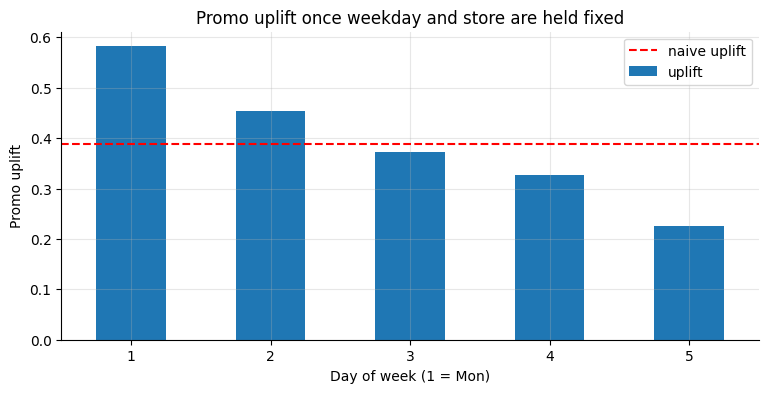

In [7]:
naive = open_days.groupby("Promo").Sales.mean()
print(f"Naive comparison: promo {naive[1]:,.0f} vs no promo {naive[0]:,.0f} -> {naive[1] / naive[0] - 1:.0%} uplift")

# Express each day's sales relative to that store's own average, then compare within weekday.
open_days["rel_sales"] = open_days.Sales / open_days.groupby("Store").Sales.transform("mean")
by_dow = open_days.groupby(["DayOfWeek", "Promo"]).rel_sales.mean().unstack()
by_dow["uplift"] = by_dow[1] / by_dow[0] - 1
by_dow["promo_share_of_days"] = open_days.groupby("DayOfWeek").Promo.mean()
display(by_dow.round(2))

ax = by_dow["uplift"].dropna().plot.bar(rot=0)
ax.axhline(naive[1] / naive[0] - 1, color="red", ls="--", label="naive uplift")
ax.set(xlabel="Day of week (1 = Mon)", ylabel="Promo uplift", title="Promo uplift once weekday and store are held fixed")
ax.legend()
plt.show()

**Finding.** Even restricted to open days, the raw comparison shows about +39%. (Leaving closed days in, which have zero sales and sit mostly in the no-promo group, would inflate it to about +81%, which is why section 2 matters.) Promos also run only Monday to Friday, so promo days are never weekends. Comparing like with like (same weekday, each store against its own average) gives an **uneven** uplift: roughly +58% on Mondays, falling to +23% on Fridays.

**Decision.** Do not quote a single promo number: the +39% average blends a large Monday effect with a small Friday one. Let the model learn promo interactions with day of week. For the planned **scenario simulation** ("what if we run a promo?"), say that estimates are associational and still confounded by how promos were scheduled. Describe the result as an estimate with limits, not a causal effect.

## 7. Weekdays and Sundays: a selection effect

**Question:** Sunday looks like a high-sales day. Is it?

In [8]:
wk = train.groupby("DayOfWeek").agg(open_share=("Open", "mean"))
wk["avg_sales_open_days"] = open_days.groupby("DayOfWeek").Sales.mean()
display(wk.round(3))

# Are the stores that open on Sundays a different set of stores?
sunday_stores = train[(train.DayOfWeek == 7) & (train.Open == 1)].Store.unique()
mon_sat = open_days[open_days.DayOfWeek <= 6]
is_sun_store = mon_sat.Store.isin(sunday_stores)
print(f"stores open on Sundays: {len(sunday_stores)} of {train.Store.nunique()}")
print(f"Mon-Sat average, Sunday-open stores : {mon_sat[is_sun_store].Sales.mean():,.0f}")
print(f"Mon-Sat average, all other stores   : {mon_sat[~is_sun_store].Sales.mean():,.0f}")
print(f"Sunday average, Sunday-open stores  : {open_days[open_days.DayOfWeek == 7].Sales.mean():,.0f}")

,open_share,avg_sales_open_days
DayOfWeek,,
1,0.950,8216.252
2,0.988,7088.409
3,0.974,6728.787
4,0.923,6768.215
5,0.951,7073.034
6,0.995,5875.085
7,0.025,8224.724


stores open on Sundays: 33 of 1115
Mon-Sat average, Sunday-open stores : 8,469
Mon-Sat average, all other stores   : 6,902
Sunday average, Sunday-open stores  : 8,225


**Finding.** Only 33 stores (about 2.5% of Sunday store-days) open on Sundays, and they are simply **bigger stores**: they average about 8,470 on Monday to Saturday against about 6,900 for everyone else. On Sunday those same stores average slightly *less* (about 8,225) than on their own weekdays. So Sunday's high average is a selection effect, not a better trading day.

**Decision.** Never read weekday effects from raw averages alone. Use store-specific features and let the model learn the weekday pattern per store, rather than one global weekday profile.

## 8. Competition distance

**Question:** do nearby competitors hurt sales, and how much should we worry about the missing values?

distance_quartile
closest     7332.0
near        6882.0
far         6699.0
farthest    6842.0
Name: avg_sales, dtype: float64

mean / median distance: 5405 / 2325


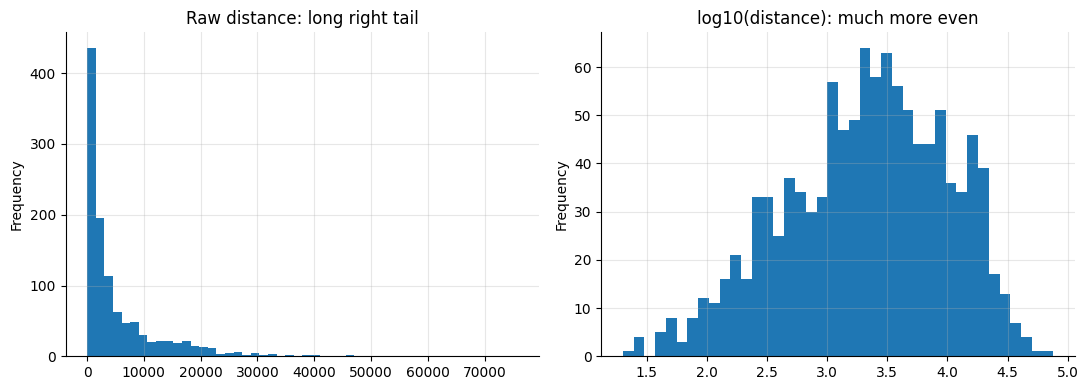

In [9]:
st = (open_days.groupby("Store").Sales.mean().rename("avg_sales").to_frame()
      .join(store_raw.set_index("Store")[["CompetitionDistance", "StoreType"]]))
st["distance_quartile"] = pd.qcut(st.CompetitionDistance, 4, labels=["closest", "near", "far", "farthest"])
display(st.groupby("distance_quartile", observed=True).avg_sales.mean().round(0))

print("mean / median distance:", round(store_raw.CompetitionDistance.mean()), "/", round(store_raw.CompetitionDistance.median()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
store_raw.CompetitionDistance.plot.hist(bins=50, ax=axes[0], title="Raw distance: long right tail")
np.log10(store_raw.CompetitionDistance.dropna()).plot.hist(bins=40, ax=axes[1], title="log10(distance): much more even")
plt.tight_layout()
plt.show()

**Finding.** The closest-competitor stores do **not** have lower sales; if anything they are slightly higher. This probably reflects busy city-centre sites where competitors cluster, so competition is correlated with footfall rather than simply harming sales. The distribution is heavily skewed (mean far above median).

**Decision.** (1) Do not assume a simple negative relationship, and let the model learn it. (2) For skew, use a log transform for linear models; tree-based models do not need it. (3) Only 3 of 1,115 stores lack a distance, so a **median fill plus a missing-flag** is proportionate. Dropping stores or building a model to predict distance would be over-engineering.

## 9. Missing-data audit of `store.csv`

**Question:** why is each value missing? The treatment depends on the reason.

In [10]:
miss = store_raw.isna().sum().rename("n_missing").to_frame()
miss["pct"] = (miss.n_missing / len(store_raw) * 100).round(1)
display(miss[miss.n_missing > 0])

promo2_cols = ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]
structurally_missing = store_raw[promo2_cols].isna().all(axis=1)
print("Promo2 fields missing exactly when Promo2 == 0:", bool((structurally_missing == (store_raw.Promo2 == 0)).all()))

print("\nPromoInterval values (note 'Sept', not 'Sep'):")
display(store_raw.PromoInterval.value_counts(dropna=False))

print("rows with no 'competition open since' date but a known distance:",
      int((store_raw.CompetitionOpenSinceYear.isna() & store_raw.CompetitionDistance.notna()).sum()))

,n_missing,pct
CompetitionDistance,3,0.3
CompetitionOpenSinceMonth,354,31.7
CompetitionOpenSinceYear,354,31.7
Promo2SinceWeek,544,48.8
Promo2SinceYear,544,48.8
PromoInterval,544,48.8


Promo2 fields missing exactly when Promo2 == 0: True

PromoInterval values (note 'Sept', not 'Sep'):


PromoInterval
NaN                 544
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64

rows with no 'competition open since' date but a known distance: 351


**Finding.** There are three different kinds of missingness:

| Columns | Missing | Reason |
|---|---|---|
| `Promo2Since*`, `PromoInterval` | 544 | **Structural**: exactly the stores with `Promo2 == 0`. The value does not exist. |
| `CompetitionDistance` | 3 | **Genuinely unknown** |
| `CompetitionOpenSince*` | 354 | Unknown open date even though a competitor exists for most of those stores |

Also, `PromoInterval` spells September as `Sept`, which breaks naive month matching.

**Decisions** (all in `load_store`):
- Structural nulls become sentinel values (`0` / `"None"`). We do not impute a promo date for a promo that never ran.
- The 3 distances get the median plus a `CompetitionDistanceMissing` flag.
- `CompetitionOpenSince*` stays NaN for now, because whether a competitor exists yet depends on the row's date. `features.py` will derive "months since competition opened".
- `parse_promo_months` maps `Sept` explicitly, with a unit test, so no September store is silently dropped.

## 10. Missing `Open` values in the test set

**Question:** 11 test rows have no `Open` flag. What do we do?

In [11]:
missing_open = test_raw[test_raw.Open.isna()]
print("stores affected:", missing_open.Store.unique())
print("weekdays affected:", sorted(int(d) for d in missing_open.DayOfWeek.unique()), "(1 = Mon, 7 = Sun)")

hist = train[(train.Store == 622) & (train.Date >= "2015-01-01")]
print("\nStore 622, share of days open by weekday in 2015:")
display(hist.groupby("DayOfWeek").Open.mean())

stores affected: [622]
weekdays affected: [1, 2, 3, 4, 5, 6] (1 = Mon, 7 = Sun)

Store 622, share of days open by weekday in 2015:


DayOfWeek
1    0.933333
2    1.000000
3    1.000000
4    0.935484
5    0.935484
6    1.000000
7    0.000000
Name: Open, dtype: float64

**Finding.** All 11 belong to **one store (622)**, on Monday to Saturday. In its own 2015 history that store is open on 93-100% of Monday to Saturday days and never on Sundays.

**Decision.** Fill as open, justified by the store's weekday pattern rather than a blanket default. This also shows the habit worth demonstrating: investigate a small anomaly before patching it.

## 11. Decision log

| # | Finding | Decision | Implemented in |
|---|---|---|---|
| 1 | Test is a 48-day block straight after train | Rolling-origin validation, never random k-fold | `validation.py` |
| 2 | Closed days always have zero sales (about 17% of rows) | Train on open days only; set closed days to 0 | `training_frame` |
| 3 | `Customers` correlates strongly but is not in test | Exclude it (leakage) | feature selection |
| 4 | Store scale varies about 8x | Store-specific baseline and features; percentage-error metric | `features.py`, `metrics.py` |
| 5 | Strong yearly seasonality, December spike | Validate across seasons; add calendar features | `validation.py`, `features.py` |
| 6 | Raw promo uplift (+39% on open days) is confounded by weekday; true uplift ranges about +58% (Mon) to +23% (Fri) | Model promo x weekday; caveat in scenario layer | `models.py`, `scenarios.py` |
| 7 | Sunday-open stores are a different group | No global weekday profile; store-specific features | `features.py` |
| 8 | Competition distance is skewed and not simply negative | Median fill plus flag; log or trees; no assumed sign | `load_store`, `features.py` |
| 9 | Promo2 nulls are structural; `Sept` spelling trap | Sentinels; explicit month map plus unit test | `load_store`, `tests/` |
| 10 | Missing `Open` is one store with a clear weekly pattern | Fill as open | `load_test` |

**Next:** build the rolling-origin validation and a per-store seasonal-naive baseline, so every later model has a number to beat.